# Emotion Recognition with ResNet
**Dataset:** AffectNet + Chinese Facial Expression (Fused & Balanced)  
**Classes:** Anger, Fear, Happy, Neutral, Sad  
**Target:** >90% Validation Accuracy

## 1. Setup & Imports

In [1]:
import os
import copy
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, OneCycleLR
from torch.utils.data import DataLoader, WeightedRandomSampler
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder
from sklearn.metrics import confusion_matrix, classification_report

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.6 GB


## 2. Configuration

In [2]:
# ─── EDIT THESE PATHS ───────────────────────────────────────────────
TRAIN_DIR = r'E:\LamMinhTri\Tai_Lieu_Hoc_Tap\2026_Semester 1\DAT301m\The_Emotion_Explorers\Mood-and-Attention-Monitoring-in-Online-Classrooms\dataset\train'   # Path to Train folder
TEST_DIR  = r'E:\LamMinhTri\Tai_Lieu_Hoc_Tap\2026_Semester 1\DAT301m\The_Emotion_Explorers\Mood-and-Attention-Monitoring-in-Online-Classrooms\dataset\test'    # Path to Test folder
# ────────────────────────────────────────────────────────────────────

# Hyperparameters
CONFIG = {
    'model'         : 'resnet50',   # resnet18 | resnet34 | resnet50
    'num_classes'   : 5,
    'img_size'      : 224,
    'batch_size'    : 32,
    'num_epochs'    : 200,
    'lr'            : 1e-3,
    'weight_decay'  : 1e-4,
    'label_smoothing': 0.1,
    'unfreeze_epoch': 5,           # Epoch to start fine-tuning backbone
    'dropout'       : 0.4,
    'checkpoint_path': 'RESNET_50_emotion_model.pth',
}

CLASSES = ['anger', 'fear', 'happy', 'neutral', 'sad']
EMOTION_EMOJI = {'anger': '😠', 'fear': '😨', 'happy': '😊', 'neutral': '😐', 'sad': '😢'}

print('Configuration:')
for k, v in CONFIG.items():
    print(f'  {k:20s}: {v}')

Configuration:
  model               : resnet50
  num_classes         : 5
  img_size            : 224
  batch_size          : 32
  num_epochs          : 200
  lr                  : 0.001
  weight_decay        : 0.0001
  label_smoothing     : 0.1
  unfreeze_epoch      : 5
  dropout             : 0.4
  checkpoint_path     : RESNET_50_emotion_model.pth


## 3. Data Loading & Augmentation

In [3]:
IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((CONFIG['img_size'] + 20, CONFIG['img_size'] + 20)),
    transforms.RandomCrop(CONFIG['img_size']),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(IMG_MEAN, IMG_STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),
])

test_transform = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(IMG_MEAN, IMG_STD),
])

train_dataset = ImageFolder(TRAIN_DIR, transform=train_transform)
test_dataset  = ImageFolder(TEST_DIR,  transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'],
                          shuffle=True, num_workers=4, pin_memory=True, drop_last=True)  # <-- Added drop_last=True
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG['batch_size'],
                          shuffle=False, num_workers=4, pin_memory=True)

print(f'Train samples : {len(train_dataset):,}')
print(f'Test  samples : {len(test_dataset):,}')
print(f'Classes       : {train_dataset.classes}')
print(f'Train batches : {len(train_loader)}')
print(f'Test  batches : {len(test_loader)}')

Train samples : 6,625
Test  samples : 6,265
Classes       : ['anger', 'fear', 'happy', 'neutral', 'sad']
Train batches : 207
Test  batches : 196


## 4. Model Architecture

In [4]:
class EmotionResNet(nn.Module):
    def __init__(self, model_name='resnet50', num_classes=5, dropout=0.4, pretrained=True):
        super().__init__()
        
        # Load backbone
        weights = 'IMAGENET1K_V2' if model_name == 'resnet50' else 'IMAGENET1K_V1'
        self.backbone = getattr(models, model_name)(weights=weights)
        
        # Freeze backbone initially
        for param in self.backbone.parameters():
            param.requires_grad = False
        
        # Enhanced classifier head
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout / 2),
            nn.Linear(256, num_classes),
        )
    
    def unfreeze_backbone(self, layers=None):
        """Unfreeze backbone layers for fine-tuning.
        layers=None unfreezes all; layers=['layer4'] unfreezes specific layers.
        """
        if layers is None:
            for param in self.backbone.parameters():
                param.requires_grad = True
        else:
            for name, param in self.backbone.named_parameters():
                if any(l in name for l in layers):
                    param.requires_grad = True
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f'  Trainable params: {trainable:,}')
    
    def forward(self, x):
        return self.backbone(x)


model = EmotionResNet(
    model_name=CONFIG['model'],
    num_classes=CONFIG['num_classes'],
    dropout=CONFIG['dropout'],
).to(device)

total_params   = sum(p.numel() for p in model.parameters())
trainable_init = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model          : {CONFIG["model"]}')
print(f'Total params   : {total_params:,}')
print(f'Trainable (now): {trainable_init:,}  (head only)')

Model          : resnet50
Total params   : 24,691,269
Trainable (now): 1,183,237  (head only)


## 5. Training Setup

In [5]:
criterion = nn.CrossEntropyLoss(label_smoothing=CONFIG['label_smoothing'])

# Initial optimizer (head only)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG['lr'],
    weight_decay=CONFIG['weight_decay'],
)

scheduler = OneCycleLR(
    optimizer,
    max_lr=CONFIG['lr'],
    steps_per_epoch=len(train_loader),
    epochs=CONFIG['num_epochs'],
    pct_start=0.1,
)

print('Loss      :', criterion)
print('Optimizer :', optimizer.__class__.__name__)
print('Scheduler :', scheduler.__class__.__name__)

Loss      : CrossEntropyLoss()
Optimizer : AdamW
Scheduler : OneCycleLR


## 6. Training Loop

In [6]:
def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        running_loss += loss.item() * imgs.size(0)
        _, preds = outputs.max(1)
        correct  += preds.eq(labels).sum().item()
        total    += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * imgs.size(0)
        _, preds = outputs.max(1)
        correct  += preds.eq(labels).sum().item()
        total    += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return running_loss / total, correct / total, all_preds, all_labels


print('Functions defined: train_epoch, evaluate')

Functions defined: train_epoch, evaluate


In [7]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
best_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

print(f"{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>8}  {'LR':>8}  {'Time':>6}")
print('─' * 75)

for epoch in range(1, CONFIG['num_epochs'] + 1):
    t0 = time.time()

    # Progressive unfreezing
    if epoch == CONFIG['unfreeze_epoch']:
        print(f'\n[Epoch {epoch}] Unfreezing layer4 for fine-tuning...')
        model.unfreeze_backbone(layers=['layer4'])
        # Update optimizer to include newly unfrozen params
        optimizer = optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=CONFIG['lr'] / 10,
            weight_decay=CONFIG['weight_decay'],
        )
        scheduler = OneCycleLR(
            optimizer,
            max_lr=CONFIG['lr'] / 10,
            steps_per_epoch=len(train_loader),
            epochs=CONFIG['num_epochs'] - epoch + 1,
        )
        print()

    if epoch == CONFIG['unfreeze_epoch'] + 5:
        print(f'\n[Epoch {epoch}] Unfreezing all backbone layers...')
        model.unfreeze_backbone(layers=None)
        optimizer = optim.AdamW(
            [
                {'params': [p for n, p in model.backbone.named_parameters() if 'fc' not in n],
                 'lr': CONFIG['lr'] / 100},
                {'params': model.backbone.fc.parameters(),
                 'lr': CONFIG['lr'] / 10},
            ],
            weight_decay=CONFIG['weight_decay'],
        )
        scheduler = CosineAnnealingLR(
            optimizer,
            T_max=CONFIG['num_epochs'] - epoch,
            eta_min=1e-7,
        )
        print()

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, criterion, device)
    val_loss, val_acc, _, _ = evaluate(model, test_loader, criterion, device)
    elapsed = time.time() - t0

    current_lr = optimizer.param_groups[0]['lr']
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    flag = ' ★' if val_acc > best_acc else ''
    print(f'{epoch:>5}  {train_loss:>10.4f}  {train_acc:>8.2%}  {val_loss:>8.4f}  '
          f'{val_acc:>7.2%}  {current_lr:>8.2e}  {elapsed:>5.1f}s{flag}')

    if val_acc > best_acc:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save({
            'epoch': epoch,
            'model_state_dict': best_model_wts,
            'val_acc': best_acc,
            'config': CONFIG,
        }, CONFIG['checkpoint_path'])

print(f'\n Best Validation Accuracy: {best_acc:.2%}')
model.load_state_dict(best_model_wts)

Epoch  Train Loss  Train Acc  Val Loss   Val Acc        LR    Time
───────────────────────────────────────────────────────────────────────────
    1      1.4696    33.80%    1.2748   48.97%  4.59e-05   59.7s ★
    2      1.2787    46.68%    1.1580   55.00%  6.35e-05   58.7s ★
    3      1.2112    51.18%    1.1114   56.65%  9.23e-05   60.9s ★
    4      1.1704    54.03%    1.0824   58.58%  1.32e-04   58.3s ★

[Epoch 5] Unfreezing layer4 for fine-tuning...
  Trainable params: 16,147,973

    5      1.1337    56.94%    1.0735   59.22%  4.07e-06   60.4s ★
    6      1.1164    58.24%    1.0639   60.24%  4.27e-06   60.7s ★
    7      1.1087    58.80%    1.0534   61.18%  4.62e-06   60.5s ★
    8      1.1035    59.57%    1.0435   61.87%  5.09e-06   60.4s ★
    9      1.0839    60.24%    1.0358   62.28%  5.70e-06   61.5s ★

[Epoch 10] Unfreezing all backbone layers...
  Trainable params: 24,691,269

   10      1.0695    61.82%    1.0052   64.10%  2.94e-07   82.2s ★
   11      1.0394    63.69%  

<All keys matched successfully>

## 8. Training Visualization

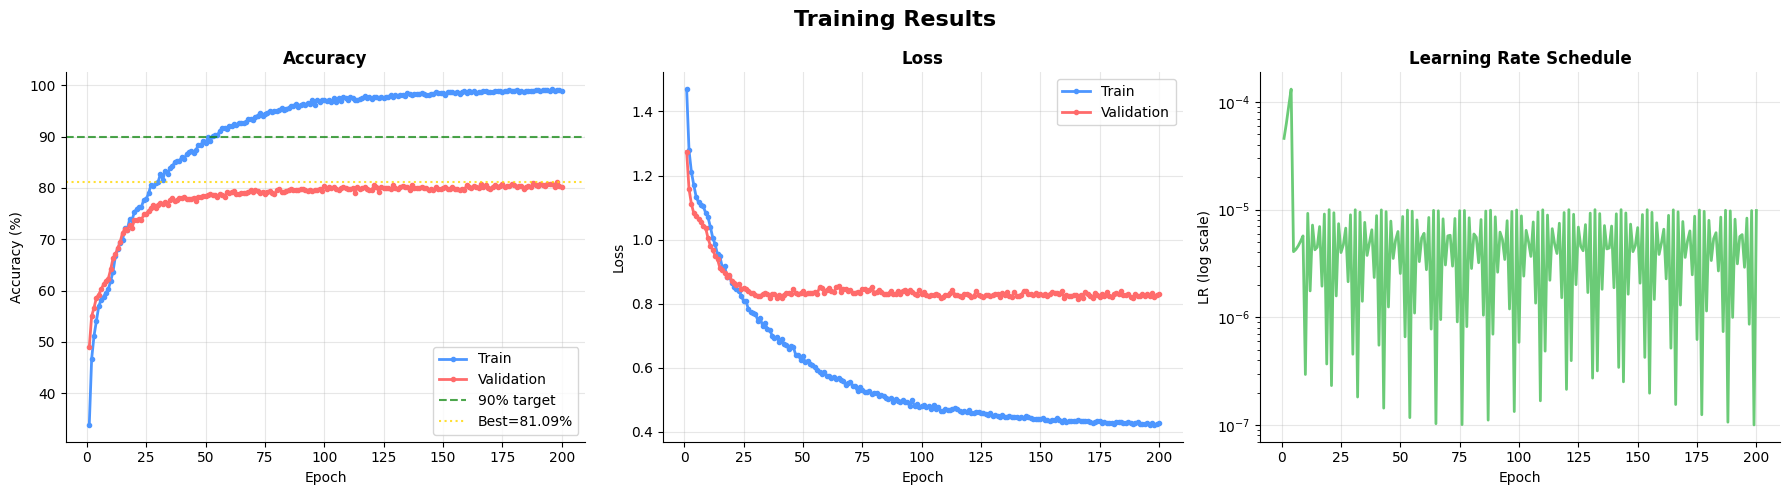

In [14]:
epochs_range = range(1, len(history['train_acc']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training Results', fontsize=16, fontweight='bold')

palette = {'train': '#4D96FF', 'val': '#FF6B6B'}

# Accuracy
ax = axes[0]
ax.plot(epochs_range, [a * 100 for a in history['train_acc']], color=palette['train'],
        linewidth=2, marker='o', markersize=3, label='Train')
ax.plot(epochs_range, [a * 100 for a in history['val_acc']], color=palette['val'],
        linewidth=2, marker='o', markersize=3, label='Validation')
ax.axhline(90, linestyle='--', color='green', alpha=0.7, label='90% target')
ax.axhline(best_acc * 100, linestyle=':', color='gold', alpha=0.8, label=f'Best={best_acc:.2%}')
ax.set_title('Accuracy', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.legend(); ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Loss
ax = axes[1]
ax.plot(epochs_range, history['train_loss'], color=palette['train'],
        linewidth=2, marker='o', markersize=3, label='Train')
ax.plot(epochs_range, history['val_loss'], color=palette['val'],
        linewidth=2, marker='o', markersize=3, label='Validation')
ax.set_title('Loss', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Learning Rate
ax = axes[2]
ax.semilogy(epochs_range, history['lr'], color='#6BCB77', linewidth=2)
ax.set_title('Learning Rate Schedule', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('LR (log scale)')
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Evaluation & Confusion Matrix

In [15]:
_, test_acc, all_preds, all_labels = evaluate(model, test_loader, criterion, device)
print(f'Test Accuracy : {test_acc:.4f} ({test_acc:.2%})')
print()
print(classification_report(all_labels, all_preds,
                             target_names=CLASSES, digits=4))

Test Accuracy : 0.8109 (81.09%)

              precision    recall  f1-score   support

       anger     0.7479    0.7127    0.7299      1253
        fear     0.7754    0.7382    0.7563      1253
       happy     0.9151    0.9122    0.9137      1253
     neutral     0.9014    0.9194    0.9103      1253
         sad     0.7158    0.7717    0.7427      1253

    accuracy                         0.8109      6265
   macro avg     0.8111    0.8109    0.8106      6265
weighted avg     0.8111    0.8109    0.8106      6265



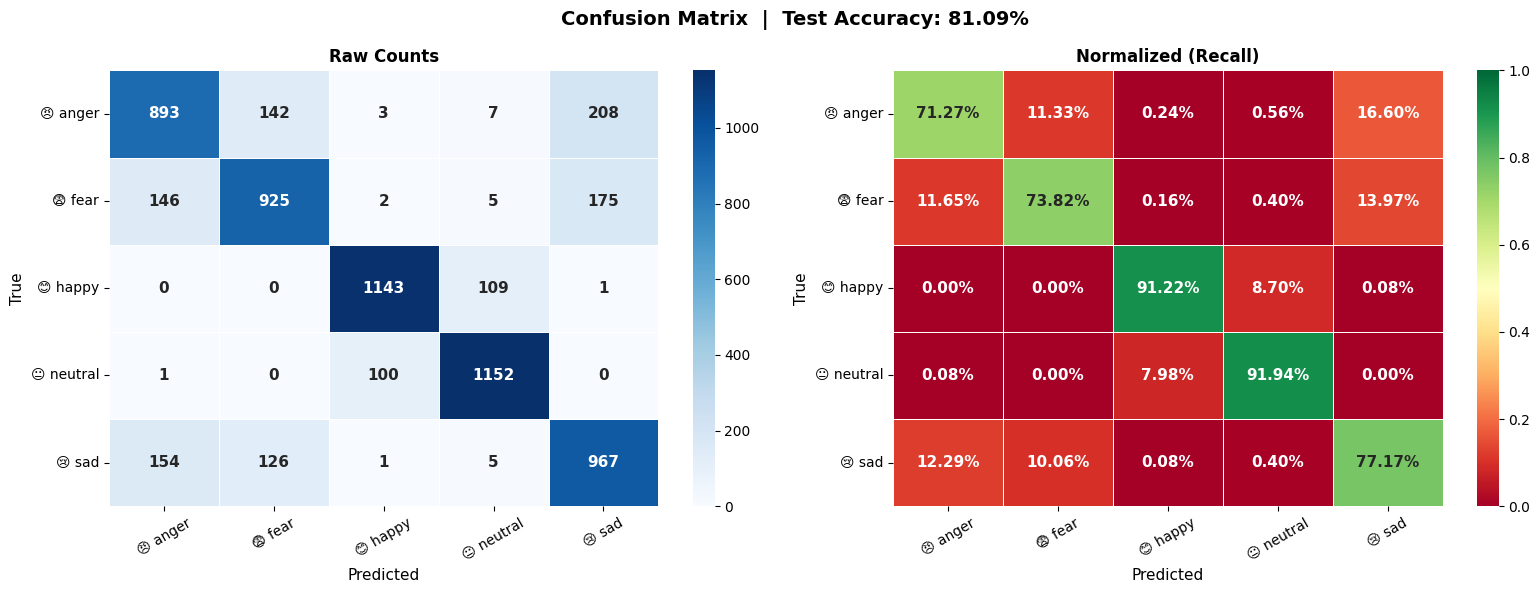

In [16]:
cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Confusion Matrix  |  Test Accuracy: {test_acc:.2%}', fontsize=14, fontweight='bold')

labels_with_emoji = [f'{EMOTION_EMOJI[c]} {c}' for c in CLASSES]

for ax, data, fmt, title, cmap in [
    (axes[0], cm,            'd',    'Raw Counts',           'Blues'),
    (axes[1], cm_normalized, '.2%',  'Normalized (Recall)',  'RdYlGn'),
]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap=cmap, ax=ax,
                xticklabels=labels_with_emoji, yticklabels=labels_with_emoji,
                linewidths=0.5, linecolor='white',
                annot_kws={'size': 11, 'weight': 'bold'},
                vmin=0 if fmt == 'd' else 0, vmax=None if fmt == 'd' else 1)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('True', fontsize=11)
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Per-Class Accuracy & Error Analysis

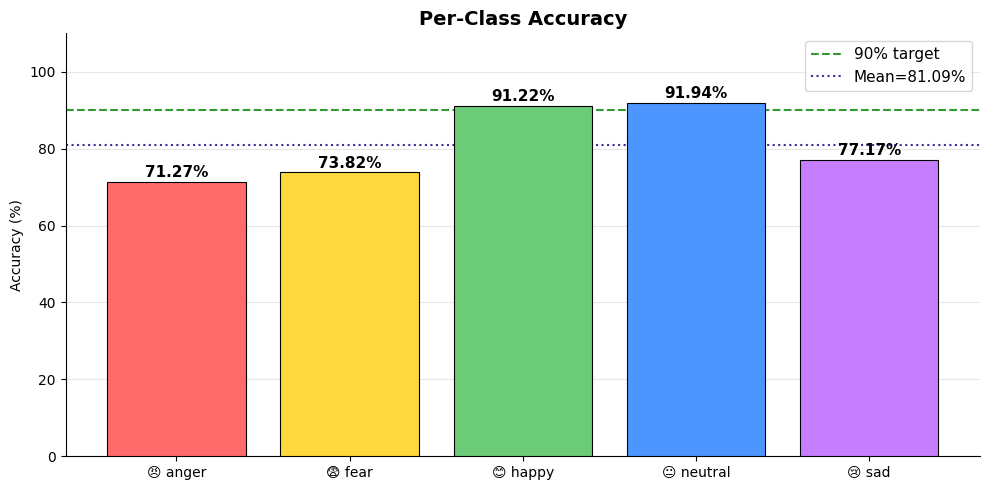


─── Per-Class Accuracy Summary ───
  ⚠️ anger   : █████████████████████░░░░░░░░░ 71.27%
  ⚠️ fear    : ██████████████████████░░░░░░░░ 73.82%
  ✅ happy   : ███████████████████████████░░░ 91.22%
  ✅ neutral : ███████████████████████████░░░ 91.94%
  ⚠️ sad     : ███████████████████████░░░░░░░ 77.17%

  Overall Test Accuracy : 81.09%
  Best Val Accuracy     : 81.09%


In [17]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = ['#FF6B6B', '#FFD93D', '#6BCB77', '#4D96FF', '#C77DFF']
bars = ax.bar(labels_with_emoji, per_class_acc * 100, color=colors_bar,
              edgecolor='black', linewidth=0.8, zorder=3)

ax.axhline(90, linestyle='--', color='green', alpha=0.8, linewidth=1.5, label='90% target', zorder=2)
ax.axhline(per_class_acc.mean() * 100, linestyle=':', color='navy', alpha=0.8,
           linewidth=1.5, label=f'Mean={per_class_acc.mean():.2%}', zorder=2)

for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.2%}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('Per-Class Accuracy', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 110)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, zorder=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print('\n─── Per-Class Accuracy Summary ───')
for cls, acc in zip(CLASSES, per_class_acc):
    status = '✅' if acc >= 0.90 else '⚠️'
    bar_len = int(acc * 30)
    print(f'  {status} {cls:8s}: {"█" * bar_len}{"░" * (30 - bar_len)} {acc:.2%}')
print(f'\n  Overall Test Accuracy : {test_acc:.2%}')
print(f'  Best Val Accuracy     : {best_acc:.2%}')

## 11. Inference on New Images

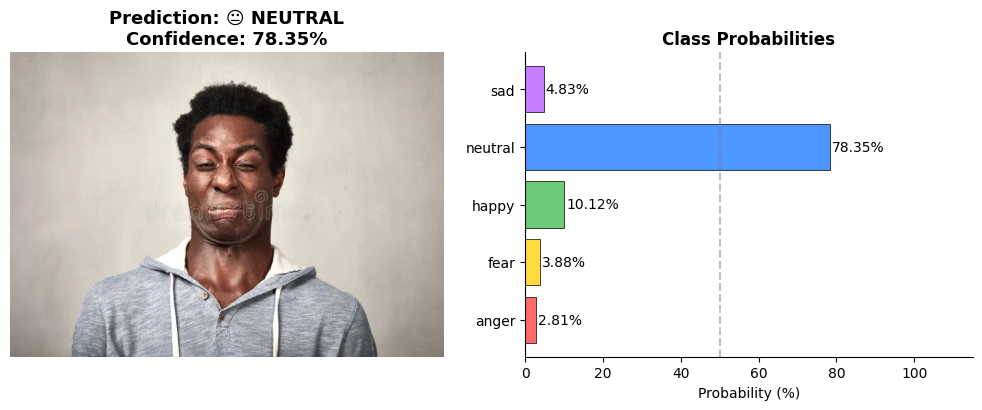

predict_image() is ready!
Usage: predicted_class, probs = predict_image("your_image.jpg", model, test_transform, CLASSES, device)


In [21]:
def predict_image(image_path, model, transform, class_names, device):
    """Predict emotion for a single image."""
    model.eval()
    img = Image.open(image_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(tensor)
        probs  = torch.softmax(output, dim=1).squeeze().cpu().numpy()
        pred   = probs.argmax()
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img)
    axes[0].set_title(f'Prediction: {EMOTION_EMOJI[class_names[pred]]} {class_names[pred].upper()}\n'
                      f'Confidence: {probs[pred]:.2%}', fontsize=13, fontweight='bold')
    axes[0].axis('off')
    
    colors_pred = ['#FF6B6B', '#FFD93D', '#6BCB77', '#4D96FF', '#C77DFF']
    bars = axes[1].barh(class_names, probs * 100, color=colors_pred, edgecolor='black', linewidth=0.5)
    axes[1].axvline(50, linestyle='--', color='gray', alpha=0.5)
    for bar, p in zip(bars, probs):
        axes[1].text(p * 100 + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{p:.2%}', va='center', fontsize=10)
    axes[1].set_xlim(0, 115)
    axes[1].set_xlabel('Probability (%)')
    axes[1].set_title('Class Probabilities', fontweight='bold')
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    return class_names[pred], probs


# Example usage — replace with your image path:
predicted_class, probabilities = predict_image(
    r"C:\Users\LENOVO\Downloads\man-disgusted-black-disgust-face-expressions-portrait-over-gray-background-81947523.webp", model, test_transform, CLASSES, device
)

print('predict_image() is ready!')
print('Usage: predicted_class, probs = predict_image("your_image.jpg", model, test_transform, CLASSES, device)')

## 12. Load Checkpoint & Resume

In [22]:
# To load the saved best model:
checkpoint = torch.load(CONFIG['checkpoint_path'], map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded checkpoint from epoch {checkpoint['epoch']} with val_acc={checkpoint['val_acc']:.2%}")

print(f'Best model saved to: {CONFIG["checkpoint_path"]}')
print(f'Final Summary:')
print(f'  Model          : {CONFIG["model"]}')
print(f'  Best Val Acc   : {best_acc:.2%}')
print(f'  Test Acc       : {test_acc:.2%}')
print(f'  Target Reached : {"✅ YES" if best_acc >= 0.90 else "❌ NO - consider more epochs or data augmentation"}')

Loaded checkpoint from epoch 198 with val_acc=81.09%
Best model saved to: RESNET_50_emotion_model.pth
Final Summary:
  Model          : resnet50
  Best Val Acc   : 81.09%
  Test Acc       : 81.09%
  Target Reached : ❌ NO - consider more epochs or data augmentation


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15596\1096178592.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CONFIG['checkpoint_path'], map_loca